# Random Graph Generation

Adjacency matrix:
[[1 1 0 0 1 0 0 0 1 0]
 [1 1 0 1 0 0 0 1 0 1]
 [0 0 1 0 1 1 0 1 1 1]
 [0 1 0 1 1 0 0 0 0 1]
 [1 0 1 1 1 0 1 0 0 0]
 [0 0 1 0 0 1 0 1 0 1]
 [0 0 0 0 1 0 1 0 0 0]
 [0 1 1 0 0 1 0 1 0 0]
 [1 0 1 0 0 0 0 0 1 0]
 [0 1 1 1 0 1 0 0 0 1]]


/tmp/ipykernel_665066/2652298322.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


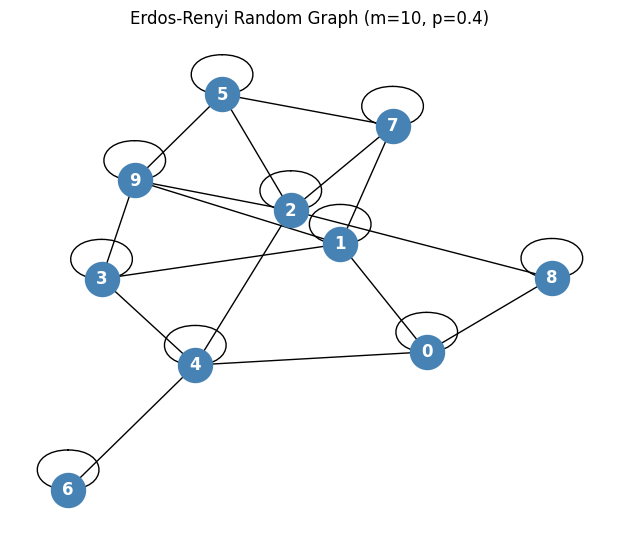

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from graph import erdos_renyi_graph

seed = 0
m = 10
p = 0.4
A = erdos_renyi_graph(m=m, p=p, seed=seed)

print("Adjacency matrix:")
print(A.astype(int))

G = nx.from_numpy_array(A)
plt.figure(figsize=(6, 5))
nx.draw(G, with_labels=True, node_color="steelblue", node_size=600, font_color="white", font_weight="bold")
plt.title(f"Erdos-Renyi Random Graph (m={m}, p={p})")
plt.tight_layout()
plt.show()


# Kemeny Constant

In [ ]:
from graph import random_chain
from optimize import _grad_kemeny, make_project_Q_bar, projected_gradient_descent

K_final = np.inf
while K_final > 100:
    # Random stationary distribution
    pi_bar = np.random.dirichlet(5 * np.ones(len(A)))

    # Random initial ergodic flow
    Q0 = random_chain(A, seed=seed)
    project_fn = make_project_Q_bar(A, pi_bar)
    Q0 = project_fn(Q0)

    # Projected gradient descent to minimize the Kemeny constant
    Q_opt, history = projected_gradient_descent(Q0, _grad_kemeny, project_fn, alpha=1e-5, n_iter=100, tol=1e-2)
    K_initial = history[0]
    K_final = history[-1]

print(f"\nInitial Kemeny: {K_initial:.4f}")
print(f"Final Kemeny:   {K_final:.4f}")

print(f"Adjacency matrix:\n {A.astype(int)}")
np.set_printoptions(precision=6, suppress=True)
print(f"Final Q:\n {np.round(Q_opt, 4)}")

print("pi_bar:", np.round(pi_bar, 4))
print(f"Final row sums: {np.round(Q_opt.sum(axis=1), 4)}")
print(f"Final col sums: {np.round(Q_opt.sum(axis=0), 4)}")

plt.figure(figsize=(7, 4))
plt.plot(history)
plt.xlabel("Iteration")
plt.ylabel("Kemeny constant")
plt.title("Projected Gradient Descent: Kemeny Minimization")
plt.tight_layout()
plt.show()


In [ ]:
from graph import degree_lifting, random_chain
from optimize import _grad_lifted_kemeny, make_project_Q, projected_gradient_descent

# --- Degree lifting: node j gets deg(j) virtual states ---
V = degree_lifting(A)
n, m = V.shape

print(f"Physical nodes m={m}, lifted states n={n}")
# print("V:\n", V)

# --- Random initialization in the lifted space ---
eps = 1e-6
Q_opt_ceil = (Q_opt > eps).astype(int)
A_lift = V @ Q_opt_ceil @ V.T
print("A_lift:\n", A_lift.astype(int))
Q_lift_init = random_chain(A_lift, seed=seed)

# Project onto the feasible lifting set of Q_opt (Eq. 34)
project_fn_lift = make_project_Q(Q_opt, V)
Q_lift_0 = project_fn_lift(Q_lift_init)

val_init, _ = _grad_lifted_kemeny(Q_lift_0, V, pi_bar)
K_opt, _ = _grad_kemeny(Q_opt)
print(f"\nK^lift (initial):    {val_init:.4f}")
print(f"K(Q_opt) [upper bd]: {K_opt:.4f}")

# --- PGD to minimize K^lift subject to Q being a lifting of Q_opt ---
grad_fn_lift = lambda Q: _grad_lifted_kemeny(Q, V, pi_bar)
Q_lift_opt, history_lift = projected_gradient_descent(
    Q_lift_0, grad_fn_lift, project_fn_lift, alpha=1e-5, n_iter=100, tol=1e-2
)

print(f"\nK^lift initial:  {history_lift[0]:.4f}")
print(f"K^lift final:    {history_lift[-1]:.4f}")
print(f"K(Q_opt):        {K_opt:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(history_lift)
plt.xlabel("Iteration")
plt.ylabel(r"$\mathcal{K}^\mathrm{lift}(P)$")
plt.title("PGD: Lifted Kemeny Minimization")
plt.tight_layout()
plt.show()


# Stackelberg Game Metric

Attack duration tau: [3 3 3 3 3 3 3 3 3 3]
Softmin temperature: 0.001 -> 1e-06

Initial J: 0.0027
Final J:   0.0062
Final Q:
 [[0.9999 0.2841 0.     0.     0.7737 0.     0.     0.     0.5509 0.    ]
 [0.2559 0.0053 0.     0.0236 0.     0.     0.     0.5523 0.     0.4275]
 [0.     0.     0.9746 0.     0.7143 0.3827 0.     0.9789 0.6655 0.6424]
 [0.     0.044  0.     1.     0.4818 0.     0.     0.     0.     0.3731]
 [0.8166 0.     0.6207 0.5326 0.7468 0.     0.3885 0.     0.     0.    ]
 [0.     0.     0.4528 0.     0.     0.2646 0.     0.7596 0.     0.0092]
 [0.     0.     0.     0.     0.3885 0.     0.3989 0.     0.     0.    ]
 [0.     0.5135 0.9971 0.     0.     0.7801 0.     0.983  0.     0.    ]
 [0.5363 0.     0.6801 0.     0.     0.     0.     0.     0.2299 0.    ]
 [0.     0.4177 0.6331 0.3426 0.     0.0588 0.     0.     0.     0.9999]]


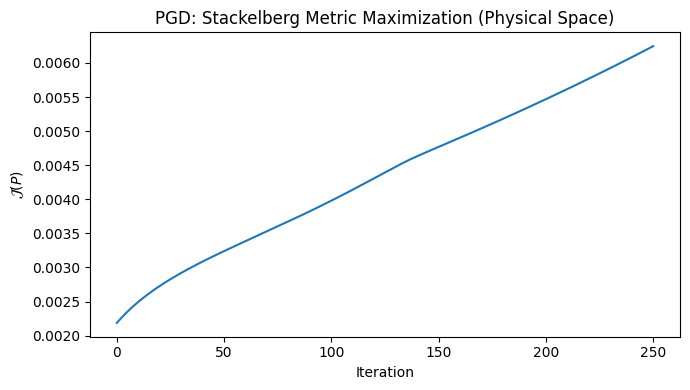

In [ ]:
import networkx as nx
from graph import random_chain
from optimize import make_grad_stackelberg, make_project_Q_bar, projected_gradient_descent
from metrics import stackelberg
from markov import ergodic_flow_to_transition

# Attack duration tau: set uniformly to the graph diameter (smallest duration that
# guarantees nonzero capture probability from any node to any other, Sec. IX)
A_no_self = A - np.diag(np.diag(A))
diameter = nx.diameter(nx.from_numpy_array(A_no_self))
tau = diameter * np.ones(m, dtype=int)

# V defaults to I_m, collapsing the lifted Stackelberg metric to the standard
# physical-space metric J(P) (Eq. 38)
grad_stackelberg = make_grad_stackelberg(tau)
# Free stationary distribution; epsilon=0 since the metric itself penalizes
# reducibility (Sec. IX)
project_fn_stb = make_project_Q_bar(A, pi_bar=None, epsilon=0.0)

# J is to be maximized, so PGD minimizes the negated metric/gradient. Anneal the
# softmin temperature from temp0 (smooth, informative gradients early on) down to
# temp_min (tight approximation to the true min(Psi_lift)) via geometric decay.
n_iter_stb = 250
temp0, temp_min = 1e-3, 1e-6
temp_decay = (temp_min / temp0) ** (1 / n_iter_stb)
temp_schedule_stb = lambda k: temp0 * temp_decay ** k
neg_grad_stackelberg = lambda Q, lse_temp: tuple(-x for x in grad_stackelberg(Q, lse_temp))

Q0 = random_chain(A, seed=seed)
Q0 = project_fn_stb(Q0)

Q_opt, hist = projected_gradient_descent(
    Q0, neg_grad_stackelberg, project_fn_stb, alpha=1, n_iter=n_iter_stb, tol=1e-6,
    temp_schedule=temp_schedule_stb,
)

print(f"Attack duration tau: {tau}")
print(f"Softmin temperature: {temp0:.4g} -> {temp_min:.4g}")

P0 = ergodic_flow_to_transition(Q0)
J_initial = stackelberg(P0, tau)
P_opt = ergodic_flow_to_transition(Q_opt)
J_final = stackelberg(P_opt, tau)

print(f"\nInitial J: {J_initial:.4f}")
print(f"Final J:   {J_final:.4f}")

np.set_printoptions(precision=6, suppress=True)
print(f"Final Q:\n {np.round(Q_opt, 4)}")

plt.figure(figsize=(7, 4))
plt.plot([-v for v in hist])
plt.xlabel("Iteration")
plt.ylabel(r"$\mathcal{J}(P)$")
plt.title("PGD: Stackelberg Metric Maximization (Physical Space)")
plt.tight_layout()
plt.show()


Physical nodes m=10, lifted states n=32
Q_lift_0:
 [[0.0245 0.     0.     ... 0.     0.     0.    ]
 [0.     0.1935 0.     ... 0.     0.     0.    ]
 [0.     0.     0.     ... 0.     0.     0.    ]
 ...
 [0.     0.     0.     ... 0.     0.     0.    ]
 [0.     0.     0.     ... 0.     0.     0.    ]
 [0.     0.     0.     ... 0.     0.     0.1893]]

Initial J_lift: 0.0222
J(Q_opt):        0.0676
Final J_lift:   0.1099


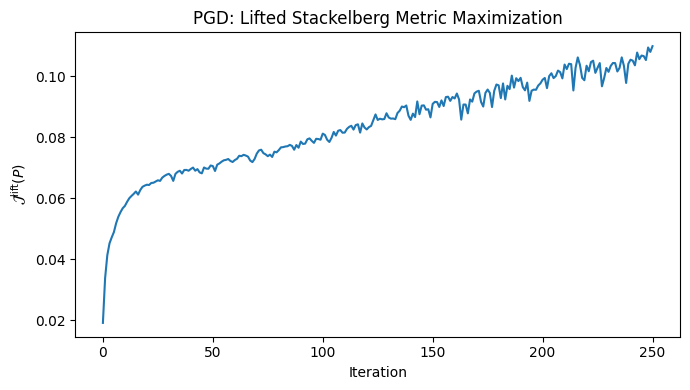

In [3]:
from graph import degree_lifting, random_chain
from optimize import make_grad_stackelberg, make_project_Q, projected_gradient_descent
from metrics import lifted_stackelberg
from markov import ergodic_flow_to_transition

# --- Degree lifting: node j gets deg(j) virtual states ---
V = degree_lifting(A)
n, m = V.shape

print(f"Physical nodes m={m}, lifted states n={n}")

# --- Random initialization in the lifted space ---
eps = 1e-6
Q_opt_ceil = (Q_opt > eps).astype(int)
A_lift = V @ Q_opt_ceil @ V.T
Q_lift_init = random_chain(A_lift, seed=seed)

# Project onto the feasible lifting set of Q_opt (Eq. 34); epsilon=0 since the
# metric itself penalizes reducibility (Sec. IX)
project_fn_lift = make_project_Q(Q_opt, V, epsilon=0.0)
Q_lift_0 = project_fn_lift(Q_lift_init)

# print Q_lift_0
print(f"Q_lift_0:\n {np.round(Q_lift_0, 4)}")

P0 = ergodic_flow_to_transition((Q_lift_0 + Q_lift_0.T)/2)
J_initial = lifted_stackelberg(P0, V, tau)
print(f"\nInitial J_lift: {J_initial:.4f}")

# V = I_m recovers the physical-space metric, so grad_stackelberg from the previous
# cell still gives J(Q_opt); grad_lifted_stackelberg uses the degree-lifting V
grad_lifted_stackelberg = make_grad_stackelberg(tau, V)
neg_grad_lifted_stackelberg = lambda Q, lse_temp: tuple(-x for x in grad_lifted_stackelberg(Q, lse_temp))

# --- PGD to maximize J^lift subject to Q being a lifting of Q_opt; reuse the same
# temp0 -> temp_min annealing schedule as the physical-space run above ---
n_iter_lift = 250
temp_schedule_lift = lambda k: temp0 * temp_decay ** k
Q_lift_opt, history_lift = projected_gradient_descent(
    Q_lift_0, neg_grad_lifted_stackelberg, project_fn_lift, alpha=0.1, n_iter=n_iter_lift, tol=1e-6,
    temp_schedule=temp_schedule_lift,
)

print(f"J(Q_opt):        {J_final:.4f}")
P_opt = ergodic_flow_to_transition(Q_lift_opt)
J_final = lifted_stackelberg(P_opt, V, tau)

print(f"Final J_lift:   {J_final:.4f}")

plt.figure(figsize=(7, 4))
plt.plot([-v for v in history_lift])
plt.xlabel("Iteration")
plt.ylabel(r"$\mathcal{J}^\mathrm{lift}(P)$")
plt.title("PGD: Lifted Stackelberg Metric Maximization")
plt.tight_layout()
plt.show()
